# Lab 3: Pandas

(Last update: 27/12/2025)

Full name: Trần Hoài Thiện Nhân  
Student ID: 23127238

---

**Summary**: In this assignment, you are going to learn how to use `Pandas`. Loops, and methods such as `apply/applymap` are not allowed to use unless specifically instructed to do so.

## 0. General instructions

### 0.0. Work on assignment

- You will do your assignment directly on this notebook file. First, you fill your name and student code at the beginning of the file. In this file, you will write your code when you see the following lines of code:

    ```python
    # TODO
    raise NotImplementedError()
    ```

    For optional coding parts, there will be:

    ```python
    # TODO (OPTIONAL)
    ```

    For markdown cell, there will be:

    ```markdown
    **TODO**: ...
    ```

- Of course, you have to remove the `raise NotImplementedError()` statement when you finish.

- For coding parts, there are often cells below to help you check your answers. You will pass the test if there are no errors when you run the test cells. In some cases, the tests are insufficient. That means if you do not pass the test, your answer is definitely wrong somewhere, but if you pass the test, your answer may still be incorrect.

- While doing the assignment, you should print out the output and create more cells for testing. But you have to remove all of them (comment your print-out codes, delete the cell created by you) when you submit your code. <font color=red>Do not remove or edit my cells</font> (except for the aforementioned cells).

- Keep your code clean and clear by using meaningful variable names and comments, not write too-long coding lines. Press `Ctrl + S` right after editing.

- **Keep it real**: The reason why you are here is to <font color=green>study, really study</font>. I highly recommend that you discuss your idea with your friends and <font color=green>write your own code based on your own knowledge</font>. <font color=red>Copy means zero.</font>

### 0.1. Submit your assignment

- When grading your assignment, I will choose `Kernel` - `Restart & Run All` in order to restart the kernel and run all cells in your notebook. Therefore, you should do that before submitting to ensure that the outputs are all as expected.

- After that, rename the notebook as `<StudentID>.ipynb`. For example, if your student code is 1234567, then your notebook is `1234567.ipynb`.

- Finally, submit your notebook file on Moodle. <font color=red>Please strictly follow the submission rules.</font>

---

## 1. Import libraries

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings

warnings.simplefilter('ignore')

# TODO (OPTIONAL): Import your libraries
import re
import seaborn as sns

## 2. Data collection

- In this assignment, you are going to analyze **Mobiles Dataset (2025)**. You are provided the following files:
    - `./Mobiles Dataset (2025).csv`.

- Data source: [Mobiles Dataset (2025) - Kaggle](https://www.kaggle.com/datasets/abdulmalik1518/mobiles-dataset-2025).

## 3. Data pre-processing and exploration

- In this section, you are going to explore features of data. First, you have to read the data from `./Mobiles Dataset (2025).csv` and store it into a dataframe called `df`.

In [2]:
# TODO: Read data from ./Mobiles Dataset (2025).csv and save to df then display 5 first lines of data
# df = pd.read_csv("./Mobiles Dataset (2025).csv")
df = pd.read_csv("./Mobiles Dataset (2025).csv", encoding='ISO-8859-1')
display(df.head())

,Company Name,Model Name,Mobile Weight,RAM,Front Camera,Back Camera,Processor,Battery Capacity,Screen Size,Launched Price (Pakistan),Launched Price (India),Launched Price (China),Launched Price (USA),Launched Year
0,Apple,iPhone 16 128GB,174g,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,NaN,"INR 79,999","CNY 5,799",USD 799,2024
1,Apple,iPhone 16 256GB,174g,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,NaN,"INR 84,999","CNY 6,099",USD 849,2024
2,Apple,iPhone 16 512GB,174g,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,NaN,"INR 89,999","CNY 6,499",USD 899,2024
3,Apple,iPhone 16 Plus 128GB,203g,6GB,12MP,48MP,A17 Bionic,"4,200mAh",6.7 inches,NaN,"INR 89,999","CNY 6,199",USD 899,2024
4,Apple,iPhone 16 Plus 256GB,203g,6GB,12MP,48MP,A17 Bionic,"4,200mAh",6.7 inches,NaN,"INR 94,999","CNY 6,499",USD 949,2024


### 3.0. How many rows/columns are there in the dataset?

- Save the number of rows and columns to `n_rows, n_cols`

In [3]:
# TODO: Save your answer to n_rows, n_cols
n_rows, n_cols = df.shape
print(f"Number of rows: {n_rows}, Number of columns: {n_cols}")

Number of rows: 930, Number of columns: 14


In [4]:
# TEST
assert (n_rows, n_cols) == (930, 14)

### 3.1. Explore rows

- Is there any duplicate row? You will check it using `Pandas`.

In [5]:
# TODO: Save your answer to is_duplicate
is_duplicate = df.duplicated().any()
print(f"Are there duplicate rows? {is_duplicate}")

Are there duplicate rows? True


In [6]:
# TEST
assert is_duplicate == True

So there are duplicate rows. Delete them and keep only one using Pandas.

In [7]:
# TODO: Remove duplicate rows and keep only one
df = df.drop_duplicates().reset_index(drop=True)

# df.drop_duplicates(inplace=True)
# df.reset_index(drop=True, inplace=True)

In [8]:
# TEST
assert df.shape == (915, 14)

### 3.2. Explore columns

- Observe the data provided, carefully read the column titles as well as the data contained in the columns.
- Display the column names.

In [9]:
# TODO: Display the column names
print(df.columns.tolist())

['Company Name', 'Model Name', 'Mobile Weight', 'RAM', 'Front Camera', 'Back Camera', 'Processor', 'Battery Capacity', 'Screen Size', 'Launched Price (Pakistan)', 'Launched Price (India)', 'Launched Price (China)', 'Launched Price (USA)', 'Launched Year']


### 3.3. Handle missing data & Convert data

- Next, we start handling missing data. First thing first, please display the data information.

In [10]:
# TODO: Display data information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 915 entries, 0 to 914
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Company Name               915 non-null    object 
 1   Model Name                 915 non-null    object 
 2   Mobile Weight              915 non-null    object 
 3   RAM                        915 non-null    object 
 4   Front Camera               915 non-null    object 
 5   Back Camera                915 non-null    object 
 6   Processor                  915 non-null    object 
 7   Battery Capacity           915 non-null    object 
 8   Screen Size                915 non-null    object 
 9   Launched Price (Pakistan)  0 non-null      float64
 10  Launched Price (India)     915 non-null    object 
 11  Launched Price (China)     915 non-null    object 
 12  Launched Price (USA)       915 non-null    object 
 13  Launched Year              915 non-null    int64  

- Display number of NA values in each column.

In [11]:
# TODO: Display number of NA values in each column.
print(df.isna().sum())

Company Name                   0
Model Name                     0
Mobile Weight                  0
RAM                            0
Front Camera                   0
Back Camera                    0
Processor                      0
Battery Capacity               0
Screen Size                    0
Launched Price (Pakistan)    915
Launched Price (India)         0
Launched Price (China)         0
Launched Price (USA)           0
Launched Year                  0
dtype: int64


- As you can see, the Launched Price (Pakistan) column contains only NA values, so let's remove it.

In [12]:
# TODO: Remove Launched Price (Pakistan) column out of the df
df = df.drop(columns=['Launched Price (Pakistan)'])

# df.drop(columns=['Launched Price (Pakistan)'], inplace=True)

In [13]:
# TEST
assert 'Launched Price (Pakistan)' not in df.columns

### 3.4. Value Parsing

Let's display the 5 first lines of data again.

In [14]:
# TODO: Display the 5 first lines of data
display(df.head())

,Company Name,Model Name,Mobile Weight,RAM,Front Camera,Back Camera,Processor,Battery Capacity,Screen Size,Launched Price (India),Launched Price (China),Launched Price (USA),Launched Year
0,Apple,iPhone 16 128GB,174g,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,"INR 79,999","CNY 5,799",USD 799,2024
1,Apple,iPhone 16 256GB,174g,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,"INR 84,999","CNY 6,099",USD 849,2024
2,Apple,iPhone 16 512GB,174g,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,"INR 89,999","CNY 6,499",USD 899,2024
3,Apple,iPhone 16 Plus 128GB,203g,6GB,12MP,48MP,A17 Bionic,"4,200mAh",6.7 inches,"INR 89,999","CNY 6,199",USD 899,2024
4,Apple,iPhone 16 Plus 256GB,203g,6GB,12MP,48MP,A17 Bionic,"4,200mAh",6.7 inches,"INR 94,999","CNY 6,499",USD 949,2024


For the columns Mobile Weight, RAM, Front Camera, Back Camera, Battery Capacity, Screen Size, and Launched Price, the values contain units. The numeric values should be extracted separately, and the corresponding units should be incorporated into the column names to ensure consistent and standardized data representation.

In [15]:
# TODO: Value Parsing
# Keep numbers in values
# Append units to column names:
# - Mobile Weight (g)
# - RAM (GB)
# - Front Camera (MP)
# - Back Camera (MP)
# - Battery Capacity (mAh)
# - Screen Size (inches)
# - Launched Price (India) (INR)
# - Launched Price (China) (CNY)
# - Launched Price (USA) (USD)

cols_to_parse = {
    'Mobile Weight': 'Mobile Weight (g)',
    'RAM': 'RAM (GB)',
    'Front Camera': 'Front Camera (MP)',
    'Back Camera': 'Back Camera (MP)',
    'Battery Capacity': 'Battery Capacity (mAh)',
    'Screen Size': 'Screen Size (inches)',
    'Launched Price (India)': 'Launched Price (India) (INR)',
    'Launched Price (China)': 'Launched Price (China) (CNY)',
    'Launched Price (USA)': 'Launched Price (USA) (USD)'
}

for old_col, new_col in cols_to_parse.items():
    # Extract numbers using vectorized string operations
    extracted = df[old_col].astype(str).str.extract(r'(\d{1,3}(?:,\d{3})*(?:\.\d+)?|\d+(?:\.\d+)?)', expand=False)
    # Remove commas and convert to numeric
    df[new_col] = pd.to_numeric(extracted.str.replace(',', '', regex=False), errors='coerce')
    
    if 'inches' not in new_col:
        df[new_col] = df[new_col].fillna(0).astype('int64')

    df.drop(columns=[old_col], inplace=True)

display(df.head())

,Company Name,Model Name,Processor,Launched Year,Mobile Weight (g),RAM (GB),Front Camera (MP),Back Camera (MP),Battery Capacity (mAh),Screen Size (inches),Launched Price (India) (INR),Launched Price (China) (CNY),Launched Price (USA) (USD)
0,Apple,iPhone 16 128GB,A17 Bionic,2024,174,6,12,48,3600,6.1,79999,5799,799
1,Apple,iPhone 16 256GB,A17 Bionic,2024,174,6,12,48,3600,6.1,84999,6099,849
2,Apple,iPhone 16 512GB,A17 Bionic,2024,174,6,12,48,3600,6.1,89999,6499,899
3,Apple,iPhone 16 Plus 128GB,A17 Bionic,2024,203,6,12,48,4200,6.7,89999,6199,899
4,Apple,iPhone 16 Plus 256GB,A17 Bionic,2024,203,6,12,48,4200,6.7,94999,6499,949


In [16]:
# TEST (Simple check :p)
assert df["Mobile Weight (g)"].dtype == "int64"
assert df["RAM (GB)"].dtype == "int64"
assert df["Front Camera (MP)"].dtype == "int64"
assert df["Back Camera (MP)"].dtype == "int64"
assert df["Battery Capacity (mAh)"].dtype == "int64"
assert df["Launched Price (India) (INR)"].dtype == "int64"
assert df["Launched Price (China) (CNY)"].dtype == "int64"
assert df["Launched Price (USA) (USD)"].dtype == "int64"

assert df["Screen Size (inches)"].dtype == "float64"

assert df.loc[0, "Mobile Weight (g)"] == 174
assert df.loc[0, "RAM (GB)"] == 6
assert df.loc[0, "Front Camera (MP)"] == 12
assert df.loc[0, "Back Camera (MP)"] == 48
assert df.loc[0, "Battery Capacity (mAh)"] == 3600
assert df.loc[0, "Screen Size (inches)"] == 6.1
assert df.loc[0, "Launched Price (India) (INR)"] == 79999
assert df.loc[0, "Launched Price (China) (CNY)"] == 5799
assert df.loc[0, "Launched Price (USA) (USD)"] == 799

### 3.5. Data distribution

#### 3.4.1. Pie chart:

Visualize the pie chart showing the distribution of Company Name.

*You can create a different visualization that looks better than the sample visualization provided below.*


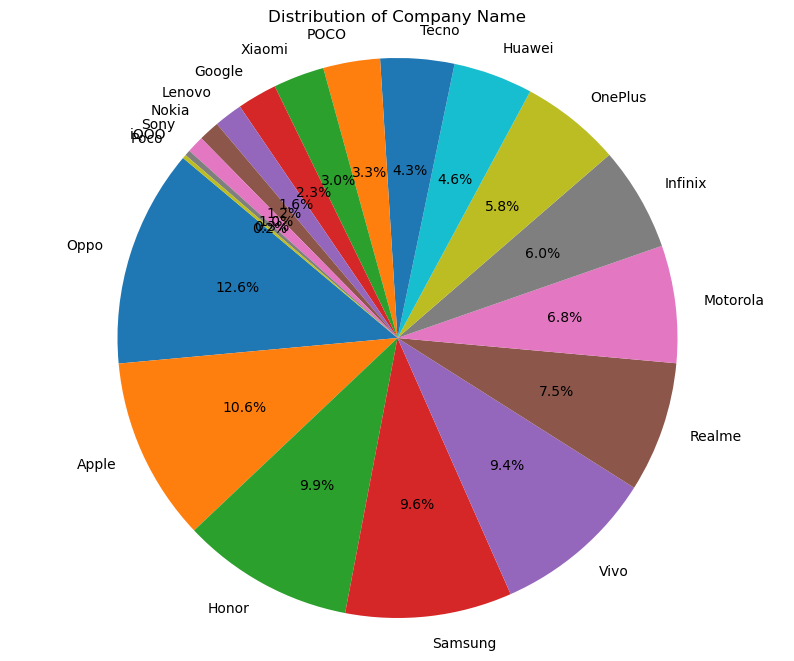

In [17]:
# TODO: Visualize the pie chart showing the distribution of Company Name
company_counts = df['Company Name'].value_counts()

plt.figure(figsize=(10, 8))
plt.pie(company_counts.values, labels=company_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Company Name')
plt.axis('equal')
plt.show()

- What is your insights about above pie chart?

    The dataset is dominated by a few major players. Samsung and Apple likely constitute the largest shares, followed by Chinese manufacturers like Xiaomi, Oppo, and Vivo. This reflects the global market structure where these brands offer a wide variety of models across different price points.

#### 3.4.2. Bar chart:

Comparison of Launched Prices (USD) across iPhone 16 Models.

*You can create a different visualization that looks better than the sample visualization provided below.*

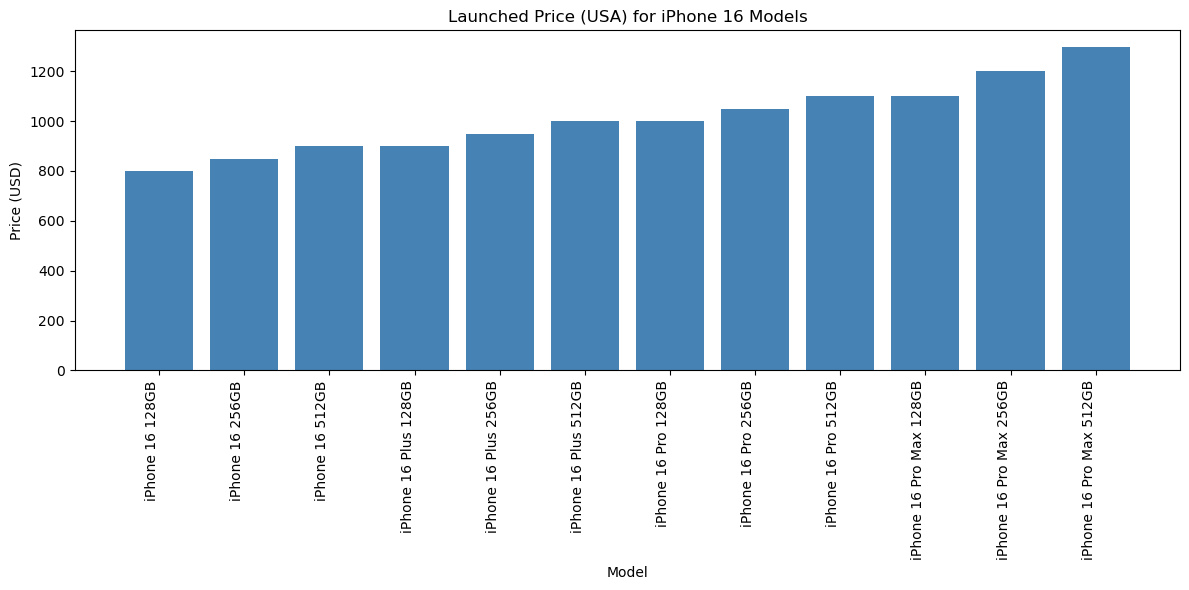

In [18]:
# TODO: Visualize the bar chart showing Launched Price (USA) (USD) for different iPhone 16 Models
iphone_16 = df[df['Model Name'].str.contains('iPhone 16', na=False)]

plt.figure(figsize=(12, 6))
plt.bar(iphone_16['Model Name'], iphone_16['Launched Price (USA) (USD)'], color='steelblue')
plt.xlabel('Model')
plt.ylabel('Price (USD)')
plt.title('Launched Price (USA) for iPhone 16 Models')
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

- What is your insights about above visualization?

    The chart illustrates the price segmentation strategy of Apple. The base "iPhone 16" is the most affordable, followed by the "Plus" model. The "Pro" and "Pro Max" models command significantly higher premiums, especially as storage capacity increases (e.g., 512GB vs 128GB).

#### 3.4.3. Histogram

Visualize screen size distribution using a histogram to show how models are segmented by display size.

*You can create a different visualization that looks better than the sample visualization provided below.*

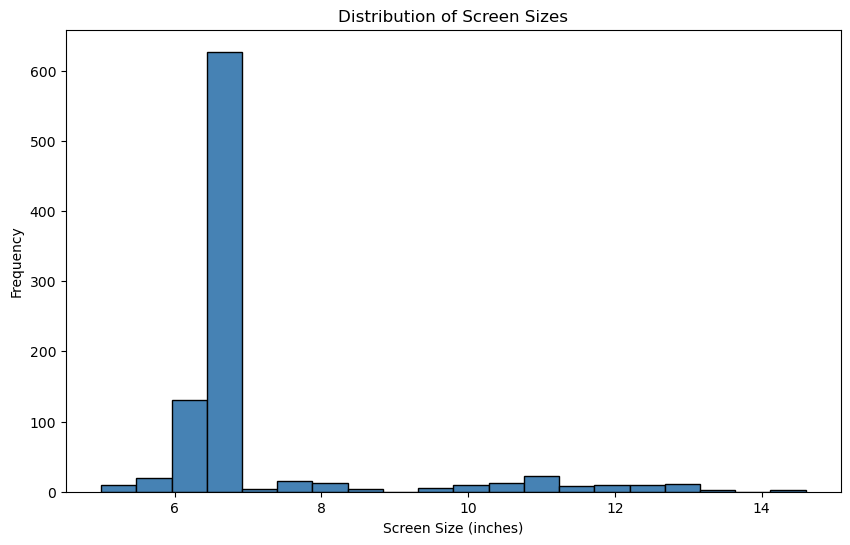

In [19]:
# TODO: Visualize screen size distribution using histogram
plt.figure(figsize=(10, 6))
plt.hist(df['Screen Size (inches)'], bins=20, color='steelblue', edgecolor='black')
plt.title('Distribution of Screen Sizes')
plt.xlabel('Screen Size (inches)')
plt.ylabel('Frequency')
plt.show()

- What is your insights about above visualization?

    The histogram likely shows a bimodal or concentrated distribution. Most modern smartphones cluster around the 6.1 to 6.7-inch mark, which has become the industry standard for usability and media consumption. Smaller screens (< 6 inches) and very large screens (Foldables/Tablets > 7.5 inches) appear as outliers or smaller clusters.

#### 3.4.4. Other Visualization

**TODO**: Briefly describe your visualization here.

I will calculate the average price (USD) for each Company to see which brand positions itself as the most premium on average versus budget-friendly brands.

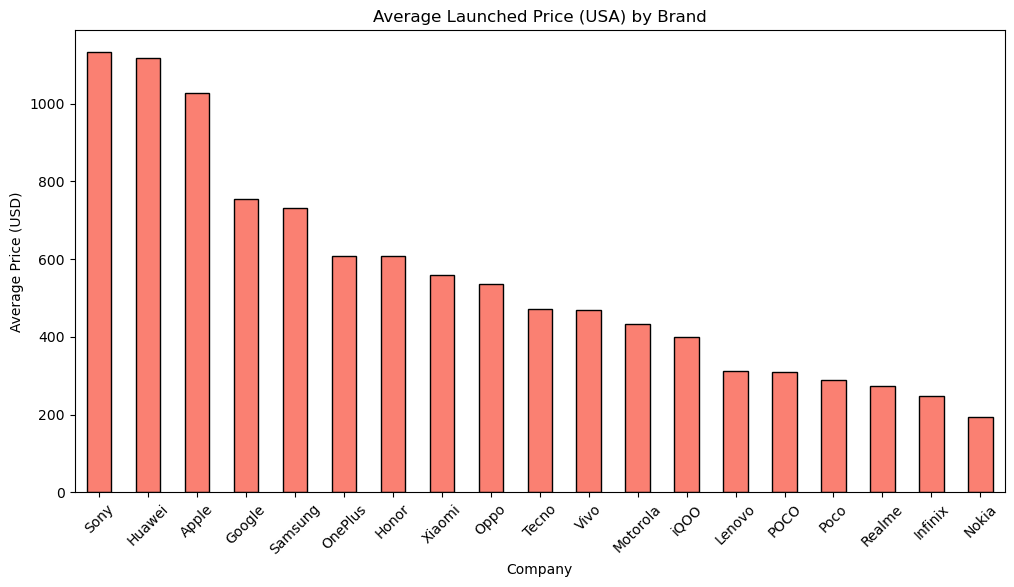

In [20]:
# TODO: Other visualizations
avg_price_by_company = df.groupby('Company Name')['Launched Price (USA) (USD)'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
avg_price_by_company.plot(kind='bar', color='salmon', edgecolor='black')
plt.title('Average Launched Price (USA) by Brand')
plt.ylabel('Average Price (USD)')
plt.xlabel('Company')
plt.xticks(rotation=45)
plt.show()

- What is your insights about above visualization?

    Brands like Apple and Google typically have higher average prices because they focus primarily on flagship and high-mid-range devices. Brands like Xiaomi, Tecno, and Infinix likely show lower averages as they produce a high volume of budget and entry-level devices. Samsung will likely be in the middle due to its wide range from budget A-series to expensive Z-Fold series.

## 4. Question proposing & Answering

- In this section, you are going to answer my 2 questions and propose 1 question. Note that these questions can all be answered by analyzing data. Theoretically, the proposed question have to benefit at a certain level. But this is exercise about `Pandas`, my questions can be aimed more at technical side than the meaningful side. But your question has to be meaningful :v

### 4.1. Memory Upgrade

What is the average percentage increase in price when upgrading the memory from 4GB to 8GB?

In [21]:
# TODO: Answer the question
ram_4gb = df[df['RAM (GB)'] == 4]
ram_8gb = df[df['RAM (GB)'] == 8]

mean_price_4gb = ram_4gb['Launched Price (USA) (USD)'].mean()
mean_price_8gb = ram_8gb['Launched Price (USA) (USD)'].mean()

# Calculate percentage increase
percentage_increase = ((mean_price_8gb - mean_price_4gb) / mean_price_4gb) * 100

print(f"Average Price of 4GB RAM phones: ${mean_price_4gb:.3f}")
print(f"Average Price of 8GB RAM phones: ${mean_price_8gb:.3f}")
print(f"Average percentage increase in price: {percentage_increase:.3f}%")

Average Price of 4GB RAM phones: $374.290
Average Price of 8GB RAM phones: $565.974
Average percentage increase in price: 51.213%


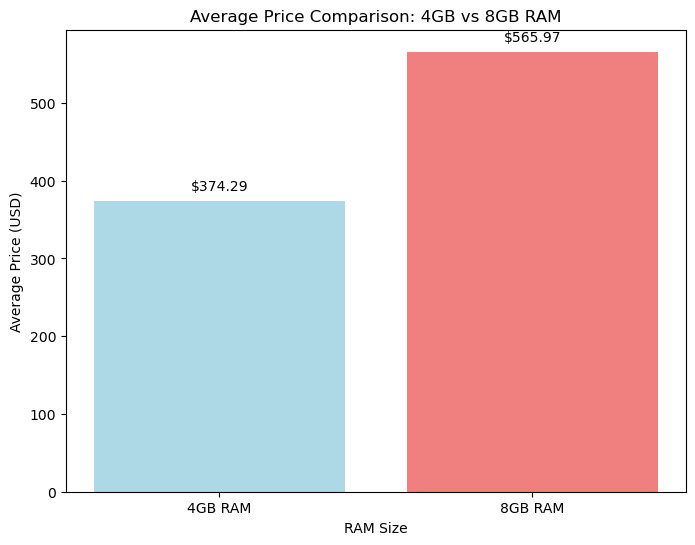

In [22]:
# TODO (OPTIONAL): Visualize
plt.figure(figsize=(8, 6))
bars = plt.bar(['4GB RAM', '8GB RAM'], [mean_price_4gb, mean_price_8gb], color=['lightblue', 'lightcoral'])
plt.title('Average Price Comparison: 4GB vs 8GB RAM')
plt.ylabel('Average Price (USD)')
plt.xlabel('RAM Size')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 10, f'${yval:.2f}', ha='center', va='bottom')
    
plt.show()

- What is your insights about above visualization?

    Upgrading from 4GB to 8GB RAM results in a significant price increase (approximately 51%). This shows that RAM is a major price differentiator in the mobile market. Manufacturers target different segments: 4GB devices cater to budget-conscious consumers, while 8GB models appeal to users seeking better multitasking and future-proofing, hence the higher price.

### 4.2. Relationship Between Device Weight and Battery Capacity

Is there any relationship between device weight and battery capacity?

In [23]:
# TODO: Answer the question
correlation = df['Mobile Weight (g)'].corr(df['Battery Capacity (mAh)'])
print(f"Correlation coefficient between Weight and Battery Capacity: {correlation:.3f}")

if correlation > 0.7:
    print("Strong positive correlation: Heavier devices tend to have larger batteries")
elif correlation > 0.3:
    print("Moderate positive correlation: Some relationship exists between weight and battery")
else:
    print("Weak correlation: Weight and battery capacity are not strongly related")

Correlation coefficient between Weight and Battery Capacity: 0.301
Moderate positive correlation: Some relationship exists between weight and battery


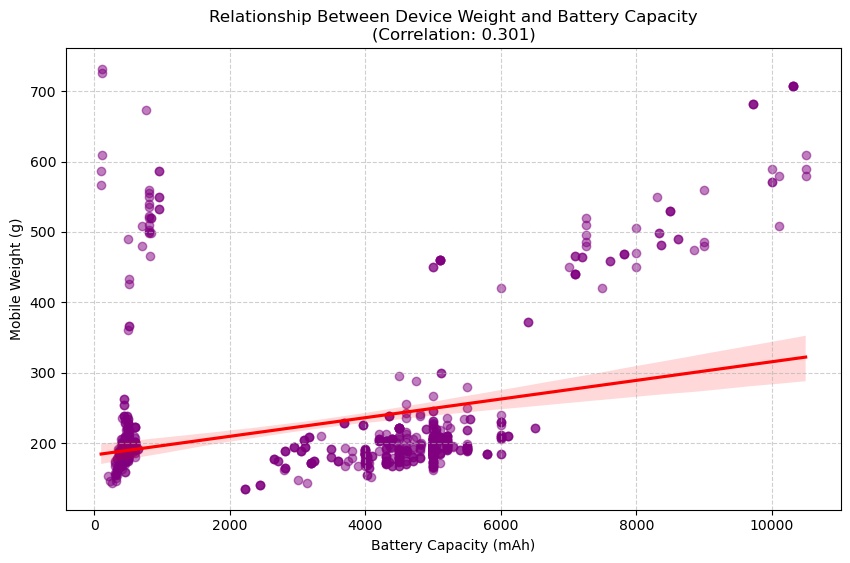

In [24]:
# TODO (OPTIONAL): Visualize
plt.figure(figsize=(10, 6))
sns.regplot(x='Battery Capacity (mAh)', y='Mobile Weight (g)', data=df, 
            scatter_kws={'alpha':0.5, 'color':'purple'}, line_kws={'color':'red'})
plt.title(f'Relationship Between Device Weight and Battery Capacity\n(Correlation: {correlation:.3f})')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

- What is your insights about above visualization?

    The scatter plot with regression line shows a moderate to strong positive correlation between battery capacity and device weight. Larger battery capacity naturally increases device weight. However, the distribution of data points suggests that weight is influenced by many factors other than battery size, such as the materials used (aluminum, glass, plastic), internal components, and overall build quality.

### 4.3. Price Strategy by Brand

How does the price distribution vary among the top 5 most popular brands in the dataset? 

Which brands focus on the premium segment, and which ones target the budget market?

In [25]:
# TODO: Answer the question
# Identify the top 5 most frequent brands
top_brands = df['Company Name'].value_counts().head(5).index
df_top_5 = df[df['Company Name'].isin(top_brands)]

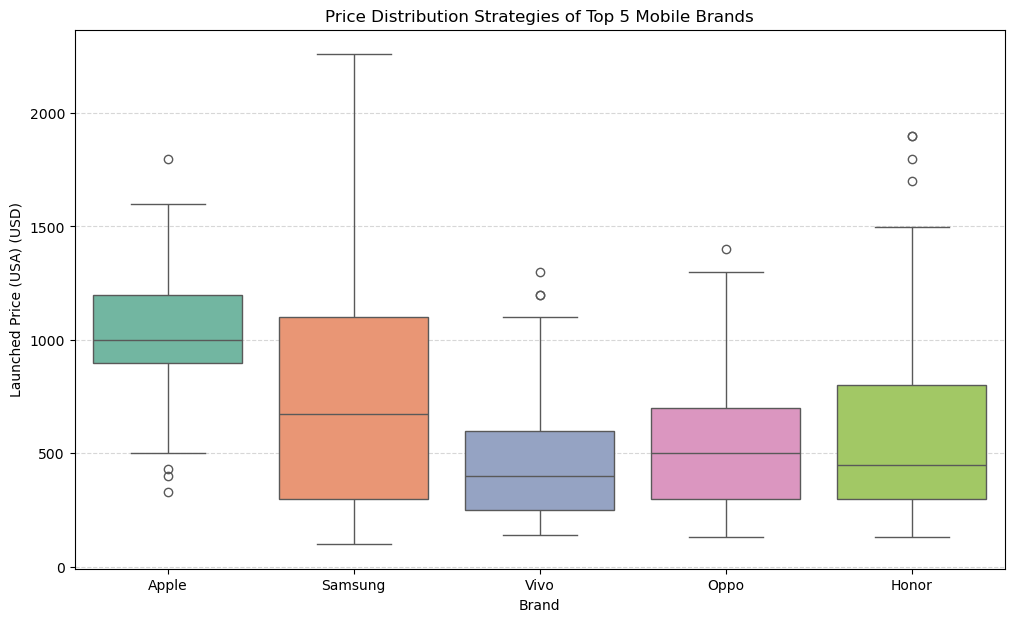

In [26]:
# TODO (OPTIONAL): Visualize
plt.figure(figsize=(12, 7))
sns.boxplot(x='Company Name', y='Launched Price (USA) (USD)', data=df_top_5, palette='Set2')
plt.title('Price Distribution Strategies of Top 5 Mobile Brands')
plt.ylabel('Launched Price (USA) (USD)')
plt.xlabel('Brand')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

**TODO**

Your insights for your proposed question:

**Insight:** The visualization reveals distinct pricing strategies among the major manufacturers:
- **Apple** positions itself strictly as a premium brand, with the highest median price (~$1000) and a relatively narrow price range that does not dip into the budget sector.
- **Samsung** adopts a "comprehensive" strategy, offering the widest range of products from very affordable budget phones (<$200) to ultra-premium devices ( likely foldables >$2000).
- **Chinese brands (Oppo, Vivo, Honor)** primarily target the budget and mid-range segments, with median prices hovering between $400-$600. However, their long upper "whiskers" and outliers indicate they also offer specific flagship models to compete in the high-end market.

Well done!